# TrashNet — Clasificador binario definitivo (TensorFlow + Optuna)

Este notebook implementa el modelo **binario reciclable / basura** usando TensorFlow/Keras.

La diferencia principal respecto del notebook PyTorch original es que aquí el segundo dataset
`dataset_gd/trash` **sí se incorpora al entrenamiento**, pero de forma controlada:

- **70%** de `dataset_gd/trash` se agrega al entrenamiento.
- **15%** se agrega a validación.
- **15%** se agrega a test.

De esta forma, el modelo aprende con más ejemplos reales de basura y, al mismo tiempo, se evita
usar las mismas imágenes para entrenar y evaluar.

## Etiquetas binarias

- `cardboard`, `glass`, `metal`, `paper`, `plastic` → **reciclable**
- `trash` de TrashNet + imágenes de `dataset_gd/trash` → **basura**

## Flujo del notebook

1. Importación de ambos datasets.
2. División reproducible de `dataset_gd/trash`.
3. Construcción de train / validation / test binarios.
4. Modelo base MobileNetV3Small.
5. Fase 1: transfer learning.
6. Fase 2: fine tuning.
7. Optimización de hiperparámetros con Optuna.
8. Reentrenamiento del modelo optimizado.
9. Calibración del umbral usando validación.
10. Comparación final sin Optuna vs. con Optuna.
11. Matrices de confusión, ROC, Precision-Recall y resumen final.

> Debido a que las clases todavía pueden quedar desbalanceadas, no se evalúa el modelo solo con
> accuracy. También se reportan **precision, recall, F1, balanced accuracy, ROC-AUC y PR-AUC**.

In [2]:
# 1. Importaciones y configuración

import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_FASE1 = 20
EPOCHS_FASE2 = 12
FINE_TUNE_LR = 1e-5

# Optuna
OPTUNA_TRIALS = 15
OPTUNA_EPOCHS = 8

# Proporción del Garbage Dataset que irá a cada split
GD_TRAIN_RATIO = 0.70
GD_VALID_RATIO = 0.15
GD_TEST_RATIO = 0.15

ORIGINAL_CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

CLASSES = ["basura", "reciclable"]

IDX_BASURA = 0
IDX_RECICLABLE = 1

EXTENSIONES = (".jpg", ".jpeg", ".png", ".webp", ".bmp")

MODEL_DIR = "modelos"
RESULTS_DIR = "predicciones"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Optuna:", optuna.__version__)
print("GPU detectada:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Optuna: 4.9.0
GPU detectada: []


In [3]:
# 2. Localizar automáticamente dataset y dataset_gd

# El notebook puede vivir en tensorflow/, PyTorch/binario/ o en la raíz.
CANDIDATOS_DATASET = [
    "../dataset",
    "../../dataset",
    "dataset"
]

CANDIDATOS_GD = [
    "../dataset_gd",
    "../../dataset_gd",
    "dataset_gd"
]

BASE_DIR = next(
    (ruta for ruta in CANDIDATOS_DATASET if os.path.isdir(ruta)),
    None
)

GD_DIR = next(
    (ruta for ruta in CANDIDATOS_GD if os.path.isdir(os.path.join(ruta, "trash"))),
    None
)

if BASE_DIR is None:
    raise FileNotFoundError(
        "No se encontró la carpeta dataset. Ajusta BASE_DIR manualmente."
    )

if GD_DIR is None:
    raise FileNotFoundError(
        "No se encontró dataset_gd/trash. Ajusta GD_DIR manualmente."
    )

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")
GD_TRASH_DIR = os.path.join(GD_DIR, "trash")

print("TrashNet:", os.path.abspath(BASE_DIR))
print("Garbage Dataset:", os.path.abspath(GD_TRASH_DIR))

TrashNet: c:\Users\tomas\OneDrive\Documentos\GitHub\Equipo_dinamita\dataset
Garbage Dataset: c:\Users\tomas\OneDrive\Documentos\GitHub\Equipo_dinamita\dataset_gd\trash


In [4]:
# 3. Validar estructura

def listar_clases(ruta):
    return sorted([
        nombre
        for nombre in os.listdir(ruta)
        if os.path.isdir(os.path.join(ruta, nombre))
    ])

def validar_split(ruta, nombre):
    if not os.path.isdir(ruta):
        raise FileNotFoundError(f"No existe {nombre}: {ruta}")

    clases = listar_clases(ruta)
    faltantes = sorted(set(ORIGINAL_CLASSES) - set(clases))

    if faltantes:
        raise ValueError(
            f"Faltan clases en {nombre}: {faltantes}"
        )

    print(f"{nombre}: {clases}")

validar_split(TRAIN_DIR, "Train")
validar_split(VALID_DIR, "Validation")
validar_split(TEST_DIR, "Test")

gd_archivos = sorted([
    str(Path(GD_TRASH_DIR) / f)
    for f in os.listdir(GD_TRASH_DIR)
    if f.lower().endswith(EXTENSIONES)
])

print(f"Garbage Dataset: {len(gd_archivos)} imágenes")

Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Validation: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Garbage Dataset: 453 imágenes


## Construcción del dataset binario

No se mueven ni duplican imágenes.

El notebook construye listas de rutas y etiquetas directamente:

- Todo lo que no sea `trash` en TrashNet → `reciclable` (1).
- `trash` de TrashNet → `basura` (0).
- `dataset_gd/trash` → `basura` (0).

El Garbage Dataset se divide una sola vez con semilla fija para evitar fuga de datos.

In [5]:
# 4. Construir listas de archivos de TrashNet

def archivos_split_trashnet(ruta_split):
    rutas = []
    etiquetas = []

    for clase in ORIGINAL_CLASSES:
        carpeta = Path(ruta_split) / clase

        archivos = sorted([
            str(carpeta / f)
            for f in os.listdir(carpeta)
            if f.lower().endswith(EXTENSIONES)
        ])

        etiqueta = (
            IDX_BASURA
            if clase == "trash"
            else IDX_RECICLABLE
        )

        rutas.extend(archivos)
        etiquetas.extend([etiqueta] * len(archivos))

    return rutas, etiquetas

train_paths_tn, train_labels_tn = archivos_split_trashnet(TRAIN_DIR)
valid_paths_tn, valid_labels_tn = archivos_split_trashnet(VALID_DIR)
test_paths_tn, test_labels_tn = archivos_split_trashnet(TEST_DIR)

print("TrashNet:")
print("Train:", len(train_paths_tn))
print("Validation:", len(valid_paths_tn))
print("Test:", len(test_paths_tn))

TrashNet:
Train: 1766
Validation: 377
Test: 384


In [6]:
# 5. Dividir dataset_gd/trash en 70% / 15% / 15%

rng = np.random.default_rng(SEED)

gd_archivos = np.array(gd_archivos)
indices = rng.permutation(len(gd_archivos))
gd_archivos = gd_archivos[indices]

n_total_gd = len(gd_archivos)
n_train_gd = int(round(n_total_gd * GD_TRAIN_RATIO))
n_valid_gd = int(round(n_total_gd * GD_VALID_RATIO))

gd_train = gd_archivos[:n_train_gd]
gd_valid = gd_archivos[n_train_gd:n_train_gd + n_valid_gd]
gd_test = gd_archivos[n_train_gd + n_valid_gd:]

# Verificación de no solapamiento
assert set(gd_train).isdisjoint(set(gd_valid))
assert set(gd_train).isdisjoint(set(gd_test))
assert set(gd_valid).isdisjoint(set(gd_test))

print("Garbage Dataset dividido:")
print(f"Train: {len(gd_train)}")
print(f"Validation: {len(gd_valid)}")
print(f"Test: {len(gd_test)}")
print(f"Total: {len(gd_train) + len(gd_valid) + len(gd_test)}")

Garbage Dataset dividido:
Train: 317
Validation: 68
Test: 68
Total: 453


In [7]:
# 6. Combinar TrashNet + Garbage Dataset

train_paths = list(train_paths_tn) + list(gd_train)
train_labels = list(train_labels_tn) + [IDX_BASURA] * len(gd_train)

valid_paths = list(valid_paths_tn) + list(gd_valid)
valid_labels = list(valid_labels_tn) + [IDX_BASURA] * len(gd_valid)

test_paths = list(test_paths_tn) + list(gd_test)
test_labels = list(test_labels_tn) + [IDX_BASURA] * len(gd_test)

def contar_binario(labels):
    labels = np.array(labels)
    return {
        "basura": int(np.sum(labels == IDX_BASURA)),
        "reciclable": int(np.sum(labels == IDX_RECICLABLE))
    }

train_count = contar_binario(train_labels)
valid_count = contar_binario(valid_labels)
test_count = contar_binario(test_labels)

print("Dataset binario definitivo:\n")

for nombre, conteo in [
    ("Train", train_count),
    ("Validation", valid_count),
    ("Test", test_count)
]:
    total = sum(conteo.values())
    print(
        f"{nombre}: {total} imágenes | "
        f"basura={conteo['basura']} | "
        f"reciclable={conteo['reciclable']} | "
        f"basura={conteo['basura']/total*100:.2f}%"
    )

Dataset binario definitivo:

Train: 2083 imágenes | basura=412 | reciclable=1671 | basura=19.78%
Validation: 445 imágenes | basura=88 | reciclable=357 | basura=19.78%
Test: 452 imágenes | basura=90 | reciclable=362 | basura=19.91%


In [8]:
# 7. Crear tf.data.Dataset

AUTOTUNE = tf.data.AUTOTUNE

def cargar_imagen(ruta, etiqueta):
    datos = tf.io.read_file(ruta)
    imagen = tf.io.decode_image(
        datos,
        channels=3,
        expand_animations=False
    )

    imagen.set_shape([None, None, 3])

    imagen = tf.image.resize(
        imagen,
        IMG_SIZE
    )

    imagen = tf.cast(imagen, tf.float32)

    return imagen, tf.cast(etiqueta, tf.int32)

def crear_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        cargar_imagen,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = crear_dataset(
    train_paths,
    train_labels,
    shuffle=True
)

valid_ds = crear_dataset(
    valid_paths,
    valid_labels,
    shuffle=False
)

test_ds = crear_dataset(
    test_paths,
    test_labels,
    shuffle=False
)

print("Datasets TensorFlow creados.")

Datasets TensorFlow creados.


In [9]:
# 8. Pesos de clase

n_basura = train_count["basura"]
n_reciclable = train_count["reciclable"]
n_total = n_basura + n_reciclable

class_weights = {
    IDX_BASURA: n_total / (2 * n_basura),
    IDX_RECICLABLE: n_total / (2 * n_reciclable)
}

print("Class weights:")
print("Basura:", round(class_weights[IDX_BASURA], 4))
print("Reciclable:", round(class_weights[IDX_RECICLABLE], 4))

Class weights:
Basura: 2.5279
Reciclable: 0.6233


In [10]:
# 9. Data augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
], name="data_augmentation")

In [11]:
# 10. Constructor del modelo binario MobileNetV3Small

def crear_modelo(
    dense_units=128,
    dropout_rate=0.30,
    learning_rate=1e-3,
    optimizer_name="adam"
):
    backbone = keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights="imagenet",
        include_preprocessing=True
    )

    backbone.trainable = False

    inputs = keras.Input(
        shape=IMG_SIZE + (3,)
    )

    x = data_augmentation(inputs)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        dense_units,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    # Salida sigmoide:
    # 0 = basura, 1 = reciclable
    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = keras.Model(
        inputs,
        outputs
    )

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )
    else:
        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model, backbone

# MODELO BASE — SIN OPTUNA

In [12]:
# 11. Crear modelo base

model_base, backbone_base = crear_modelo(
    dense_units=128,
    dropout_rate=0.30,
    learning_rate=1e-3,
    optimizer_name="adam"
)

model_base.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,105 (3.86 MB)

 Trainable params: 73,985 (289.00 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [13]:
# 12. Fase 1 — Modelo base

callbacks_base_1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_base_fase1 = model_base.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_base_1
)

Epoch 1/20


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.8060 - loss: 0.4486 - val_accuracy: 0.9191 - val_loss: 0.2123 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.9083 - loss: 0.2615 - val_accuracy: 0.9393 - val_loss: 0.1862 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9208 - loss: 0.2157 - val_accuracy: 0.9326 - val_loss: 0.1859 - learning_rate: 0.0010
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9381 - loss: 0.1895 - val_accuracy: 0.9191 - val_loss: 0.2103 - learning_rate: 0.0010
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9405 - loss: 0.1572 - val_accuracy: 0.9393 - val_loss: 0.1671 - learning_rate: 0.0010
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9539 - loss: 0.1295 - val_accuracy: 0.9528 - val_loss: 0.1429 - learning_rate: 0.0010
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9635 - loss: 0.1089 - val_accuracy: 

In [14]:
# 13. Fase 2 — Fine tuning del modelo base

backbone_base.trainable = True

for layer in backbone_base.layers[:-30]:
    layer.trainable = False

# BatchNormalization se mantiene congelada para un fine tuning más estable
for layer in backbone_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_base.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_base_2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history_base_fase2 = model_base.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_base_2
)

Epoch 1/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 158ms/step - accuracy: 0.9750 - loss: 0.0818 - val_accuracy: 0.9596 - val_loss: 0.1072
Epoch 2/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.9750 - loss: 0.0803 - val_accuracy: 0.9596 - val_loss: 0.1073
Epoch 3/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.9750 - loss: 0.0752 - val_accuracy: 0.9596 - val_loss: 0.1060
Epoch 4/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 174ms/step - accuracy: 0.9813 - loss: 0.0666 - val_accuracy: 0.9663 - val_loss: 0.1047
Epoch 5/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.9779 - loss: 0.0684 - val_accuracy: 0.9640 - val_loss: 0.1058
Epoch 6/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.9779 - loss: 0.0682 - val_accuracy: 0.9640 - val_loss: 0.1058
Epoch 7/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9774 - loss: 0.0660 - val_accuracy: 0.9596 - val_loss: 0.1063
Epoch 8/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.9837 - loss: 0.0592 - val_accu

# OPTUNA

Optuna buscará automáticamente:

- `dense_units`
- `dropout_rate`
- `learning_rate`
- optimizador

La métrica de decisión será **Average Precision (PR-AUC) para la clase basura**.

En la salida sigmoide del modelo, la red devuelve `P(reciclable)`.
Por lo tanto:

`P(basura) = 1 - P(reciclable)`

In [15]:
# 14. Funciones para etiquetas y probabilidades

def obtener_y_prob_reciclable(model, dataset):
    y_true = []
    p_reciclable = []

    for images, labels in dataset:
        probs = model.predict(
            images,
            verbose=0
        ).reshape(-1)

        y_true.extend(
            labels.numpy().reshape(-1)
        )

        p_reciclable.extend(probs)

    return (
        np.array(y_true, dtype=int),
        np.array(p_reciclable, dtype=float)
    )

y_valid_true = np.array(
    valid_labels,
    dtype=int
)

y_valid_basura = (
    y_valid_true == IDX_BASURA
).astype(int)

In [16]:
# 15. Función objetivo de Optuna

def objective(trial):
    keras.backend.clear_session()
    gc.collect()
    tf.random.set_seed(SEED)

    dense_units = trial.suggest_categorical(
        "dense_units",
        [64, 128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.20,
        0.50,
        step=0.05
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop"]
    )

    model, _ = crear_modelo(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        optimizer_name=optimizer_name
    )

    callbacks_trial = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=0
        )
    ]

    model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=OPTUNA_EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks_trial,
        verbose=0
    )

    _, p_reciclable = obtener_y_prob_reciclable(
        model,
        valid_ds
    )

    p_basura = 1.0 - p_reciclable

    average_precision = average_precision_score(
        y_valid_basura,
        p_basura
    )

    print(
        f"Trial {trial.number} | "
        f"AP basura: {average_precision:.4f}"
    )

    del model
    gc.collect()

    return average_precision

In [17]:
# 16. Ejecutar Optuna

sampler = optuna.samplers.TPESampler(
    seed=SEED
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="TrashNet_Binario_TensorFlow_Optuna"
)

study.optimize(
    objective,
    n_trials=OPTUNA_TRIALS
)

print("\nMejor trial:", study.best_trial.number)
print(f"Mejor AP basura: {study.best_value:.4f}")

print("\nMejores hiperparámetros:")
for parametro, valor in study.best_params.items():
    print(f"{parametro}: {valor}")

[I 2026-08-11 20:37:41,973] A new study created in memory with name: TrashNet_Binario_TensorFlow_Optuna



Trial 0 | AP basura: 0.7109


[I 2026-08-11 20:39:00,226] Trial 0 finished with value: 0.7109343129377806 and parameters: {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.7109343129377806.
c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Trial 1 | AP basura: 0.9622


[I 2026-08-11 20:40:17,636] Trial 1 finished with value: 0.9622434984879036 and parameters: {'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0008706020878304854, 'optimizer': 'adam'}. Best is trial 1 with value: 0.9622434984879036.
c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
[I 2026-08-11 20:41:34,809] Trial 2 finished with value: 0.891580112645761 and parameters: {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 7.309539835912905e-05, 'optimizer': 'rmsprop'}. Best is trial 1 with value: 0.9622434984879036.


...

Trial 12 | AP basura: 0.9484


[I 2026-08-11 21:06:26,242] Trial 12 finished with value: 0.9483873286768328 and parameters: {'dense_units': 64, 'dropout_rate': 0.5, 'learning_rate': 0.000980887512039779, 'optimizer': 'adam'}. Best is trial 1 with value: 0.9622434984879036.
c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Trial 13 | AP basura: 0.9464


[I 2026-08-11 21:08:19,482] Trial 13 finished with value: 0.9463896523530777 and parameters: {'dense_units': 64, 'dropout_rate': 0.45, 'learning_rate': 0.0009841513366747655, 'optimizer': 'adam'}. Best is trial 1 with value: 0.9622434984879036.
c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
[I 2026-08-11 21:12:47,368] Trial 14 finished with value: 0.9142452826875772 and parameters: {'dense_units': 64, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00019837097847729267, 'optimizer': 'adam'}. Best is trial 1 with value: 0.9622434984879036.


Trial 14 | AP basura: 0.9142

Mejor trial: 1
Mejor AP basura: 0.9622

Mejores hiperparámetros:
dense_units: 64
dropout_rate: 0.2
learning_rate: 0.0008706020878304854
optimizer: adam


In [18]:
# 17. Recuperar mejores hiperparámetros

best_params = study.best_params

BEST_DENSE_UNITS = best_params["dense_units"]
BEST_DROPOUT = best_params["dropout_rate"]
BEST_LR = best_params["learning_rate"]
BEST_OPTIMIZER = best_params["optimizer"]

print("Dense units:", BEST_DENSE_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Learning rate:", BEST_LR)
print("Optimizer:", BEST_OPTIMIZER)

Dense units: 64
Dropout: 0.2
Learning rate: 0.0008706020878304854
Optimizer: adam


# MODELO OPTIMIZADO — CON OPTUNA

In [19]:
# 18. Crear modelo optimizado

keras.backend.clear_session()
tf.random.set_seed(SEED)

model_optuna, backbone_optuna = crear_modelo(
    dense_units=BEST_DENSE_UNITS,
    dropout_rate=BEST_DROPOUT,
    learning_rate=BEST_LR,
    optimizer_name=BEST_OPTIMIZER
)

In [20]:
# 19. Fase 1 — Modelo Optuna

callbacks_optuna_1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_optuna_fase1 = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weights,
    callbacks=callbacks_optuna_1
)

Epoch 1/20


c:\Users\tomas\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 316ms/step - accuracy: 0.8185 - loss: 0.4292 - val_accuracy: 0.9011 - val_loss: 0.2787 - learning_rate: 8.7060e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.8747 - loss: 0.3039 - val_accuracy: 0.9326 - val_loss: 0.2005 - learning_rate: 8.7060e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 168ms/step - accuracy: 0.9165 - loss: 0.2411 - val_accuracy: 0.9438 - val_loss: 0.1579 - learning_rate: 8.7060e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.9309 - loss: 0.1877 - val_accuracy: 0.9528 - val_loss: 0.1439 - learning_rate: 8.7060e-04
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.9289 - loss: 0.1866 - val_accuracy: 0.9483 - val_loss: 0.1420 - learning_rate: 8.7060e-04
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 169ms/step - accuracy: 0.9443 - loss: 0.1633 - val_accuracy: 0.9393 - val_loss: 0.1664 - learning_rate: 8.7060e-04
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.93

In [21]:
# 20. Fase 2 — Fine tuning del modelo Optuna

backbone_optuna.trainable = True

for layer in backbone_optuna.layers[:-30]:
    layer.trainable = False

for layer in backbone_optuna.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_optuna.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks_optuna_2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history_optuna_fase2 = model_optuna.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weights,
    callbacks=callbacks_optuna_2
)

Epoch 1/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.9779 - loss: 0.0723 - val_accuracy: 0.9708 - val_loss: 0.1073
Epoch 2/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.9818 - loss: 0.0681 - val_accuracy: 0.9708 - val_loss: 0.1071
Epoch 3/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.9784 - loss: 0.0717 - val_accuracy: 0.9685 - val_loss: 0.1060
Epoch 4/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.9770 - loss: 0.0679 - val_accuracy: 0.9708 - val_loss: 0.1061
Epoch 5/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.9765 - loss: 0.0687 - val_accuracy: 0.9708 - val_loss: 0.1050
Epoch 6/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.9813 - loss: 0.0671 - val_accuracy: 0.9708 - val_loss: 0.1047
Epoch 7/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.9746 - loss: 0.0627 - val_accuracy: 0.9708 - val_loss: 0.1023
Epoch 8/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.9851 - loss: 0.0534 - val_accu

# CALIBRACIÓN DEL UMBRAL

No asumimos automáticamente un umbral de 0.5.

Se busca en **validación** el umbral de `P(basura)` que maximiza el F1 de basura.
Ese umbral queda fijo antes de evaluar test.

In [22]:
# 21. Calibrar umbral en validación

y_valid, p_valid_reciclable = obtener_y_prob_reciclable(
    model_optuna,
    valid_ds
)

p_valid_basura = 1.0 - p_valid_reciclable
y_valid_basura = (
    y_valid == IDX_BASURA
).astype(int)

umbrales = np.linspace(
    0.05,
    0.95,
    181
)

resultados_umbral = []

for umbral in umbrales:
    pred_basura = (
        p_valid_basura >= umbral
    ).astype(int)

    f1 = f1_score(
        y_valid_basura,
        pred_basura,
        zero_division=0
    )

    resultados_umbral.append(
        (umbral, f1)
    )

UMBRAL, MEJOR_F1_VALID = max(
    resultados_umbral,
    key=lambda x: x[1]
)

print(f"Umbral seleccionado: {UMBRAL:.3f}")
print(f"Mejor F1 basura en validación: {MEJOR_F1_VALID:.4f}")

Umbral seleccionado: 0.485
Mejor F1 basura en validación: 0.9318


In [23]:
# 22. Predicciones sobre TEST

y_true, p_base_reciclable = obtener_y_prob_reciclable(
    model_base,
    test_ds
)

_, p_optuna_reciclable = obtener_y_prob_reciclable(
    model_optuna,
    test_ds
)

p_base_basura = 1.0 - p_base_reciclable
p_optuna_basura = 1.0 - p_optuna_reciclable

# Modelo base: umbral convencional 0.5
y_pred_base = np.where(
    p_base_basura >= 0.5,
    IDX_BASURA,
    IDX_RECICLABLE
)

# Modelo Optuna: umbral calibrado en validación
y_pred_optuna = np.where(
    p_optuna_basura >= UMBRAL,
    IDX_BASURA,
    IDX_RECICLABLE
)

print("Predicciones listas.")

Predicciones listas.


In [24]:
# 23. Métricas comparativas

def calcular_metricas(
    y_real,
    y_pred,
    p_basura
):
    y_real_basura = (
        y_real == IDX_BASURA
    ).astype(int)

    y_pred_basura = (
        y_pred == IDX_BASURA
    ).astype(int)

    return {
        "Accuracy": accuracy_score(
            y_real,
            y_pred
        ),

        "Balanced accuracy": balanced_accuracy_score(
            y_real,
            y_pred
        ),

        "Precision basura": precision_score(
            y_real_basura,
            y_pred_basura,
            zero_division=0
        ),

        "Recall basura": recall_score(
            y_real_basura,
            y_pred_basura,
            zero_division=0
        ),

        "F1 basura": f1_score(
            y_real_basura,
            y_pred_basura,
            zero_division=0
        ),

        "ROC AUC basura": roc_auc_score(
            y_real_basura,
            p_basura
        ),

        "PR AUC / AP basura": average_precision_score(
            y_real_basura,
            p_basura
        )
    }

metricas_base = calcular_metricas(
    y_true,
    y_pred_base,
    p_base_basura
)

metricas_optuna = calcular_metricas(
    y_true,
    y_pred_optuna,
    p_optuna_basura
)

comparacion_df = pd.DataFrame(
    [
        metricas_base,
        metricas_optuna
    ],
    index=[
        "Sin Optuna",
        "Con Optuna"
    ]
)

display(
    comparacion_df.style.format("{:.4f}")
)

,Accuracy,Balanced accuracy,Precision basura,Recall basura,F1 basura,ROC AUC basura,PR AUC / AP basura
Sin Optuna,0.9602,0.9417,0.8913,0.9111,0.9011,0.9887,0.9672
Con Optuna,0.9624,0.9390,0.9101,0.9000,0.9050,0.9900,0.9704


In [25]:
# 24. Reportes de clasificación

print("SIN OPTUNA")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred_base,
        target_names=CLASSES,
        zero_division=0
    )
)

print("\nCON OPTUNA")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred_optuna,
        target_names=CLASSES,
        zero_division=0
    )
)

SIN OPTUNA
              precision    recall  f1-score   support

      basura       0.89      0.91      0.90        90
  reciclable       0.98      0.97      0.98       362

    accuracy                           0.96       452
   macro avg       0.93      0.94      0.94       452
weighted avg       0.96      0.96      0.96       452


CON OPTUNA
              precision    recall  f1-score   support

      basura       0.91      0.90      0.91        90
  reciclable       0.98      0.98      0.98       362

    accuracy                           0.96       452
   macro avg       0.94      0.94      0.94       452
weighted avg       0.96      0.96      0.96       452



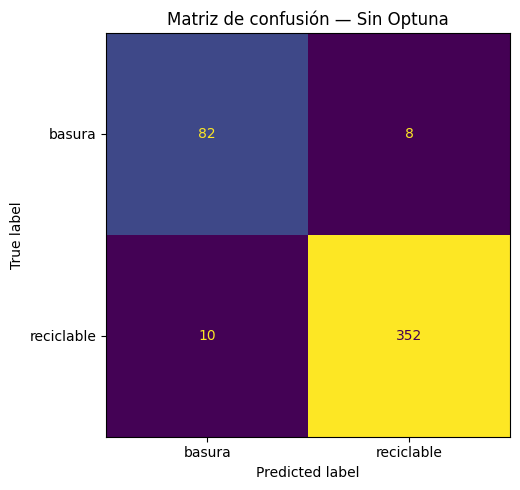

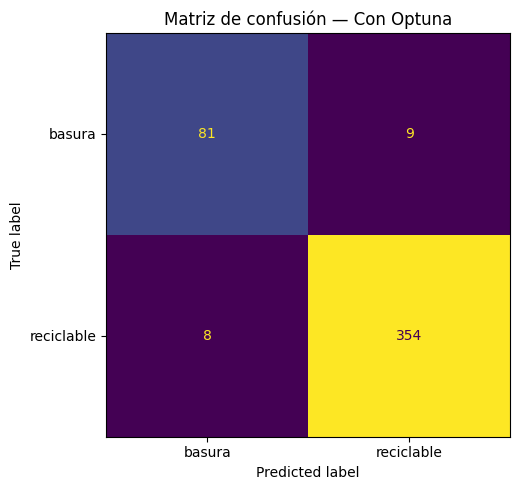

In [26]:
# 25. Matrices de confusión

cm_base = confusion_matrix(
    y_true,
    y_pred_base
)

cm_optuna = confusion_matrix(
    y_true,
    y_pred_optuna
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=CLASSES
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusión — Sin Optuna"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=CLASSES
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de confusión — Con Optuna"
)

plt.tight_layout()
plt.show()

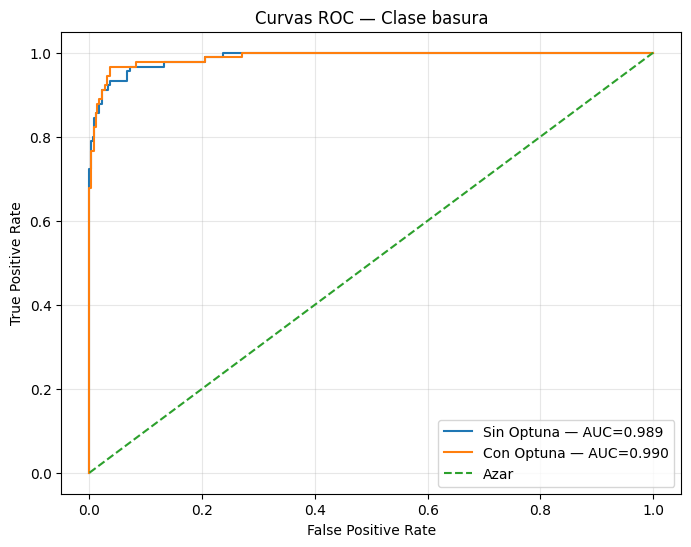

In [27]:
# 26. Curvas ROC

y_test_basura = (
    y_true == IDX_BASURA
).astype(int)

fpr_base, tpr_base, _ = roc_curve(
    y_test_basura,
    p_base_basura
)

fpr_optuna, tpr_optuna, _ = roc_curve(
    y_test_basura,
    p_optuna_basura
)

auc_base = roc_auc_score(
    y_test_basura,
    p_base_basura
)

auc_optuna = roc_auc_score(
    y_test_basura,
    p_optuna_basura
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Sin Optuna — AUC={auc_base:.3f}"
)

plt.plot(
    fpr_optuna,
    tpr_optuna,
    label=f"Con Optuna — AUC={auc_optuna:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Azar"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Curvas ROC — Clase basura"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

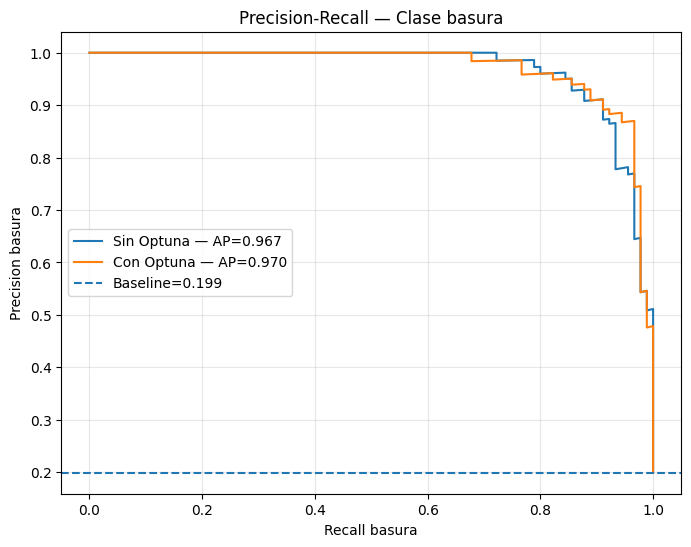

In [28]:
# 27. Curvas Precision-Recall

precision_base, recall_base, _ = precision_recall_curve(
    y_test_basura,
    p_base_basura
)

precision_optuna, recall_optuna, _ = precision_recall_curve(
    y_test_basura,
    p_optuna_basura
)

ap_base = average_precision_score(
    y_test_basura,
    p_base_basura
)

ap_optuna = average_precision_score(
    y_test_basura,
    p_optuna_basura
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_base,
    precision_base,
    label=f"Sin Optuna — AP={ap_base:.3f}"
)

plt.plot(
    recall_optuna,
    precision_optuna,
    label=f"Con Optuna — AP={ap_optuna:.3f}"
)

baseline_ap = y_test_basura.mean()

plt.axhline(
    baseline_ap,
    linestyle="--",
    label=f"Baseline={baseline_ap:.3f}"
)

plt.xlabel(
    "Recall basura"
)

plt.ylabel(
    "Precision basura"
)

plt.title(
    "Precision-Recall — Clase basura"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

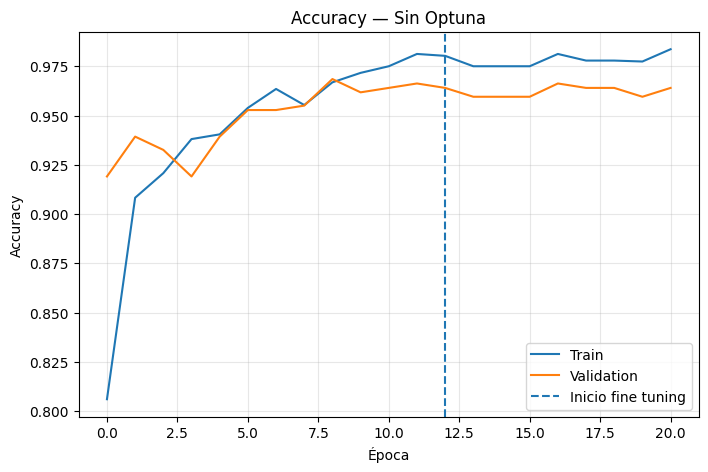

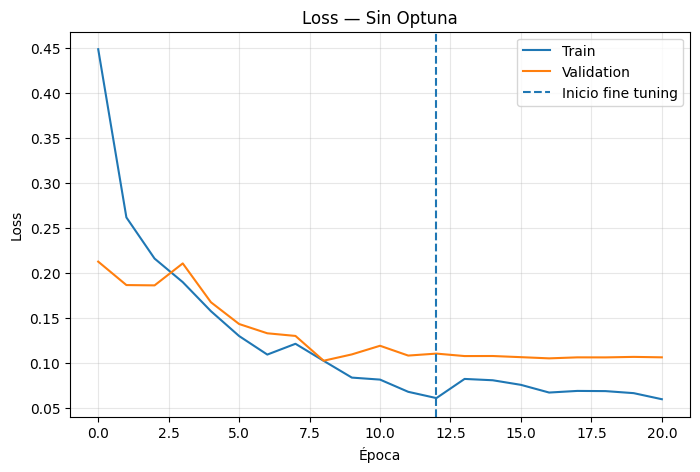

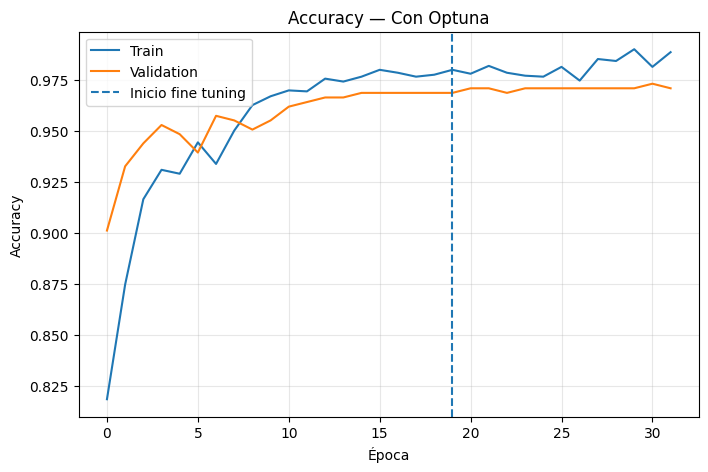

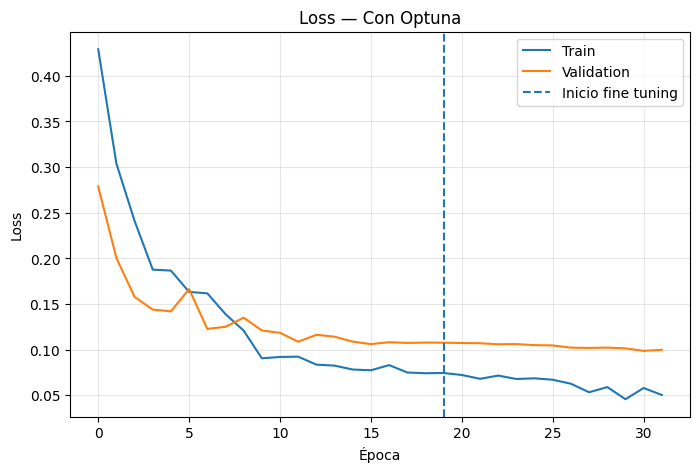

In [29]:
# 28. Curvas de entrenamiento

def combinar_historiales(
    h1,
    h2
):
    resultado = {
        "accuracy":
            h1.history.get("accuracy", []) +
            h2.history.get("accuracy", []),

        "val_accuracy":
            h1.history.get("val_accuracy", []) +
            h2.history.get("val_accuracy", []),

        "loss":
            h1.history.get("loss", []) +
            h2.history.get("loss", []),

        "val_loss":
            h1.history.get("val_loss", []) +
            h2.history.get("val_loss", [])
    }

    resultado["inicio_finetuning"] = len(
        h1.history.get("loss", [])
    )

    return resultado

hist_base = combinar_historiales(
    history_base_fase1,
    history_base_fase2
)

hist_optuna = combinar_historiales(
    history_optuna_fase1,
    history_optuna_fase2
)

def graficar_historial(
    hist,
    titulo
):
    inicio = hist["inicio_finetuning"]

    plt.figure(figsize=(8, 5))

    plt.plot(
        hist["accuracy"],
        label="Train"
    )

    plt.plot(
        hist["val_accuracy"],
        label="Validation"
    )

    plt.axvline(
        inicio - 1,
        linestyle="--",
        label="Inicio fine tuning"
    )

    plt.title(
        f"Accuracy — {titulo}"
    )

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    plt.figure(figsize=(8, 5))

    plt.plot(
        hist["loss"],
        label="Train"
    )

    plt.plot(
        hist["val_loss"],
        label="Validation"
    )

    plt.axvline(
        inicio - 1,
        linestyle="--",
        label="Inicio fine tuning"
    )

    plt.title(
        f"Loss — {titulo}"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

graficar_historial(
    hist_base,
    "Sin Optuna"
)

graficar_historial(
    hist_optuna,
    "Con Optuna"
)

In [30]:
# 29. Guardar ambos modelos

RUTA_MODELO_BASE = os.path.join(
    MODEL_DIR,
    "trashnet_binario_tensorflow_sin_optuna.keras"
)

RUTA_MODELO_OPTUNA = os.path.join(
    MODEL_DIR,
    "trashnet_binario_tensorflow_optuna.keras"
)

model_base.save(
    RUTA_MODELO_BASE
)

model_optuna.save(
    RUTA_MODELO_OPTUNA
)

print("Modelo base:", RUTA_MODELO_BASE)
print("Modelo Optuna:", RUTA_MODELO_OPTUNA)

Modelo base: modelos\trashnet_binario_tensorflow_sin_optuna.keras
Modelo Optuna: modelos\trashnet_binario_tensorflow_optuna.keras


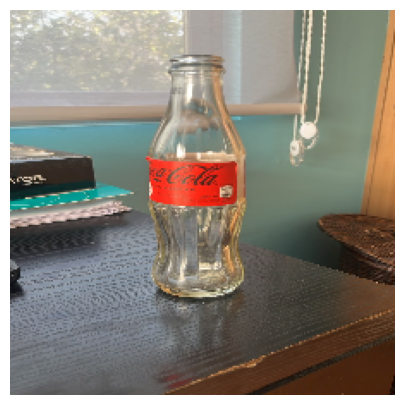

Predicción: reciclable
P(basura): 0.09%
P(reciclable): 99.91%
Umbral basura utilizado: 0.485


In [31]:
# 30. Probar una imagen externa

from tensorflow.keras.utils import (
    load_img,
    img_to_array
)

RUTA_IMAGEN = "../imagenes_a_test/test 1.jpeg"

if os.path.exists(RUTA_IMAGEN):

    img = load_img(
        RUTA_IMAGEN,
        target_size=IMG_SIZE
    )

    img_array = img_to_array(img)

    batch = np.expand_dims(
        img_array,
        axis=0
    )

    p_reciclable = float(
        model_optuna.predict(
            batch,
            verbose=0
        )[0][0]
    )

    p_basura = 1.0 - p_reciclable

    clase_predicha = (
        "basura"
        if p_basura >= UMBRAL
        else "reciclable"
    )

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Predicción:", clase_predicha)
    print(f"P(basura): {p_basura*100:.2f}%")
    print(f"P(reciclable): {p_reciclable*100:.2f}%")
    print(f"Umbral basura utilizado: {UMBRAL:.3f}")

else:

    print(
        "No se encontró la imagen. "
        "Cambia RUTA_IMAGEN por una ruta válida."
    )

In [32]:
# 31. Resumen final

print("=" * 80)
print("RESUMEN FINAL — TRASHNET BINARIO TENSORFLOW")
print("=" * 80)

print("\nDATASETS UTILIZADOS")
print("- TrashNet: train / validation / test originales")
print("- Garbage Dataset: dataset_gd/trash")
print(
    f"- División GD: "
    f"{GD_TRAIN_RATIO:.0%} train / "
    f"{GD_VALID_RATIO:.0%} validation / "
    f"{GD_TEST_RATIO:.0%} test"
)

print("\nDATASET FINAL")

for nombre, conteo in [
    ("Train", train_count),
    ("Validation", valid_count),
    ("Test", test_count)
]:
    print(
        f"- {nombre}: {sum(conteo.values())} imágenes | "
        f"{conteo['basura']} basura | "
        f"{conteo['reciclable']} reciclable"
    )

print("\nMODELO BASE — SIN OPTUNA")

for nombre, valor in metricas_base.items():
    print(
        f"- {nombre}: {valor:.4f}"
    )

print("\nOPTUNA")
print(f"- Trials: {OPTUNA_TRIALS}")
print(f"- Mejor trial: {study.best_trial.number}")
print(f"- Mejor AP basura en validación: {study.best_value:.4f}")

print("\nMEJORES HIPERPARÁMETROS")

for parametro, valor in study.best_params.items():
    print(
        f"- {parametro}: {valor}"
    )

print("\nUMBRAL")
print(
    f"- Umbral de P(basura): {UMBRAL:.3f}"
)

print("\nMODELO OPTIMIZADO — CON OPTUNA")

for nombre, valor in metricas_optuna.items():
    print(
        f"- {nombre}: {valor:.4f}"
    )

print("\nCOMPARACIÓN")

dif_accuracy = (
    metricas_optuna["Accuracy"] -
    metricas_base["Accuracy"]
) * 100

dif_f1 = (
    metricas_optuna["F1 basura"] -
    metricas_base["F1 basura"]
)

dif_ap = (
    metricas_optuna["PR AUC / AP basura"] -
    metricas_base["PR AUC / AP basura"]
)

print(
    f"- Accuracy: "
    f"{metricas_base['Accuracy']*100:.2f}% "
    f"-> {metricas_optuna['Accuracy']*100:.2f}% "
    f"({dif_accuracy:+.2f} pp)"
)

print(
    f"- F1 basura: "
    f"{metricas_base['F1 basura']:.4f} "
    f"-> {metricas_optuna['F1 basura']:.4f} "
    f"({dif_f1:+.4f})"
)

print(
    f"- AP basura: "
    f"{metricas_base['PR AUC / AP basura']:.4f} "
    f"-> {metricas_optuna['PR AUC / AP basura']:.4f} "
    f"({dif_ap:+.4f})"
)

print("\nMODELOS GUARDADOS")
print("-", RUTA_MODELO_BASE)
print("-", RUTA_MODELO_OPTUNA)

print("\n" + "=" * 80)
print("FIN DEL RESUMEN")
print("=" * 80)

RESUMEN FINAL — TRASHNET BINARIO TENSORFLOW

DATASETS UTILIZADOS
- TrashNet: train / validation / test originales
- Garbage Dataset: dataset_gd/trash
- División GD: 70% train / 15% validation / 15% test

DATASET FINAL
- Train: 2083 imágenes | 412 basura | 1671 reciclable
- Validation: 445 imágenes | 88 basura | 357 reciclable
- Test: 452 imágenes | 90 basura | 362 reciclable

MODELO BASE — SIN OPTUNA
- Accuracy: 0.9602
- Balanced accuracy: 0.9417
- Precision basura: 0.8913
- Recall basura: 0.9111
- F1 basura: 0.9011
- ROC AUC basura: 0.9887
- PR AUC / AP basura: 0.9672

OPTUNA
- Trials: 15
- Mejor trial: 1
- Mejor AP basura en validación: 0.9622

MEJORES HIPERPARÁMETROS
- dense_units: 64
- dropout_rate: 0.2
- learning_rate: 0.0008706020878304854
- optimizer: adam

UMBRAL
- Umbral de P(basura): 0.485

MODELO OPTIMIZADO — CON OPTUNA
- Accuracy: 0.9624
- Balanced accuracy: 0.9390
- Precision basura: 0.9101
- Recall basura: 0.9000
- F1 basura: 0.9050
- ROC AUC basura: 0.9900
- PR AUC / AP 

## Interpretación para la presentación

Este modelo binario utiliza **dos fuentes de datos**:

1. **TrashNet**, que aporta ejemplos reciclables y basura.
2. **Garbage Dataset**, que aporta más variedad visual a la clase basura.

El segundo dataset se divide antes del entrenamiento para garantizar que las imágenes utilizadas
en test **nunca hayan sido vistas durante el entrenamiento**.

Esto permite construir un clasificador binario más robusto que uno entrenado únicamente con las
95 imágenes de basura originales de TrashNet.

El modelo se evalúa principalmente con:

- **Recall de basura:** qué porcentaje de la basura real logra detectar.
- **Precision de basura:** cuántas de las imágenes que marcó como basura realmente lo eran.
- **F1 de basura:** equilibrio entre precision y recall.
- **Balanced Accuracy:** evita que la clase mayoritaria domine la evaluación.
- **ROC-AUC** y **PR-AUC / Average Precision:** capacidad para separar ambas clases.

Optuna busca automáticamente una mejor combinación de hiperparámetros y luego el modelo ganador
se vuelve a entrenar usando **Fase 1 + Fine Tuning**.